---
title: EDA II
---

::: {note} Learning Outcomes
- Grasp the importance of asking good questions.
- Understand the process of acquiring data.
- Learn to manipulate tabular data for your purposes.
- Figure out how to express data manipulations in plain English
- Become familiar with some conversions between plain English and commands in both `polars` and `SQL`.
:::

In [4]:
import polars as pl
import seaborn as sns
import numpy as np

sns.set_palette("colorblind")

## Examining Distributions

In the last section, we went over many different parts of the data exploration process (which we call Exploratory Data Analysis, or EDA for short) through a task focused on enrollment patterns at UC Berkeley. These parts included:

- **Asking good questions** to clarify the task at hand
- Defining **metrics for success** for the given task
- **Identifying which data is necessary** for the task
- Finding and **accessing the necessary data** (be scrappy!)
- Understanding **context** and **inspecting** properties of the data
- Looking for **extremes** in your data
- Observing the **distributions** of your data
- **Visualizing** the data in different ways that have different advantages

Importantly, we emphasized plain language descriptions for these aspects, rather than the specifics of the code used to facilitate this exploration. We will continue to emphasize this clear communication over syntax.

Let us return to our discussion of EDA, making sure to **ask good questions** at every step. For now, we will continue our examination of distributions and visualizations.

In [5]:
hs_enroll = pl.read_csv('data/pivoted-ucb-data-w-enrollment.csv')

hs_enroll = hs_enroll.with_columns(
    app_rate=pl.col('applied') / pl.col('grade_12')
)

hs_enroll = hs_enroll.filter(pl.col('app_rate').is_not_null())

hs_enroll = hs_enroll.filter(pl.col('app_rate') <= 1)

As a reminder, the above `polars` code is what we used to get the current version of our dataset.

1. We used `pl.read_csv` to read in our data.
2. We used `.with_columns` to add a new column, named `'app_rate'`, by dividing our `'applied'` count column by our `'grade_12'` enrollment column.
3. We used `.filter` to remove any `null` values of `'app_rate'`.
4. We also used `.filter` to remove schools with an ``app_rate'` greater than 1.

Here is that table sorted by `'app_rate'`, sorted from largest to smallest:

In [6]:
hs_enroll.sort('app_rate', descending=True)

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""MIDDLE COLLEGE HIGH SCHOOL""","""San Pablo""","""Contra Costa""",50,10,9,283,60,0.833333
"""MONTA VISTA HIGH SCHOOL""","""Cupertino""","""Santa Clara""",321,33,25,1636,421,0.76247
"""GRETCHEN WHITNEY HIGH SCHOOL""","""Cerritos""","""Los Angeles""",119,23,13,1018,163,0.730061
"""CALIFORNIA ACAD MATH & SCIENCE""","""Carson""","""Los Angeles""",115,24,11,667,163,0.705521
"""LYNBROOK HIGH SCHOOL""","""San Jose""","""Santa Clara""",314,34,25,1720,448,0.700893
…,…,…,…,…,…,…,…,…
"""SHAFTER HIGH SCHOOL""","""Shafter""","""Kern""",7,null,null,1655,431,0.016241
"""PERRIS HIGH SCHOOL""","""Perris""","""Riverside""",7,3,null,2106,497,0.014085
"""EXCELSIOR CHARTER SCHL VICTORV…","""Victorville""","""San Bernardino""",5,null,null,2120,371,0.013477


### Visualizing Distributions

We then used the following `polars` code to create a **histogram** of our `'app_rate'` data.

<Axes: xlabel='app_rate', ylabel='Count'>

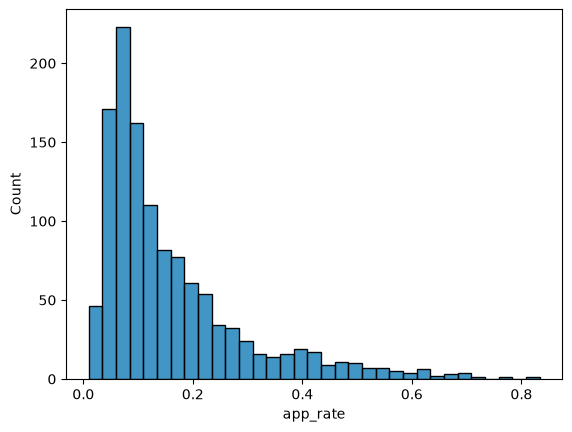

In [7]:
sns.histplot(hs_enroll, x='app_rate')

This particular histogram shows the **count** for our `'app_rate'` values, collected in bins.

Great, we're able to visualize our data! From here, we can begin to notice things about the **distribution** of our data. One important aspect of distributions is their *spread**, or **variation**. Looking at this particular distribution of `'app_rate'`, we can ask: Why is there so much variation in application rates across schools?

There are many possible reasons. Many different factors can influence the decision to apply:

- Money
- Distance
- Academic resources
- Individual and family priorities

And there are many other factors as well!

## Finding Additional Data

Do we have this data? Some of it we may not be able to access, or the data simply may not have been collected. It is important, though, to try to look for relevant data.

For now, we can go back to the [California Department of Education website](https://www.cde.ca.gov/ds/), where we found the 12th grade enrollment data for all California public schools with a 12th grade.

```{image} images/ca_doe.png
:alt: A screenshot of the California Department of Education's Data & Statistics page, which has the following description: "Obtain access to educational data, statistics, and information about California's students and schools. There are three visible links: a page titled "DataQuest," a page titled "Data Reports," and a page titled "Downloadable Data Files." Descriptions of these are in a dropdown below.
:width: 500
```

:::{dropdown} Descriptions of Links
1. DataQuest
    - The description is: "DataQuest is the CDE's public data reporting website that provides meaningful data and statistics about California's K–12 public education system."
2. Data Reports
    - The description is: "Reports with data and statistics about California's K–12 public education system."
3. Downloadable Data Files
    - The description is: "Downloadable files with data and statistics about California's K–12 public education system."
:::

As with last time, we want to select the option labeled "Downloadable Data Files," where we can find the raw files and process them ourselves. Once you select this option, you will see a [page listing various datasets](https://www.cde.ca.gov/ds/ad/downloadabledata.asp) from the California Department of Education.

For the grade 12 enrollment data, we used the dataset labeled "Annual Enrollment." There is also a dataset labeled "Free or Reduced-Price Meal (FRPM)." This information is often used as a proxy for socioeconomic status, as use of these free and reduced-price meals can be an indicator of student poverty. 

This can certainly be useful, but for now, we will use the dataset labeled "Public School and District" to explore a different factor we listed earlier: the distance of all public schools to UC Berkeley.

However, we end up with a small issue. The dataset doesn't have this exact information! The dataset does have the latitude and longitude for each school, so we once again have to be scrappy and calculate the distance using UC Berkeley's own latitude and longitude and the usual formula for calculating distance between pairs of $(x,y)$ coordinates.

In [8]:
full = pl.read_csv('data/pivoted-ucb-data-w-everything.csv')
full

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles
str,str,str,i64,i64,i64,i64,i64,str,f64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,"""N""",0.685365,372.941684
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,"""Y""",0.678421,52.249325
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,"""N""",0.832272,346.780088
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,"""N""",0.450172,14.878894
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,"""N""",0.469298,41.786639
…,…,…,…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409,"""N""",0.180556,371.43283
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133,"""N""",0.479354,148.850295
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139,"""N""",0.460692,268.05834


For now, we will provide you with a copy of our earlier dataset with this distance data already joined to it (the `'dist_to_ucb_miles'` column). This table also contains the percent of students at each school who use free and reduced-price meals (the `'pct_free_reduced'` column), as well as whether or not each school is a charter school (he `;is_charter'` column).

### Difficult Joins

One of the reasons for us dealing with this join for you behind the scenes is that this is not an entirely straightforward join.

We are joining these datasets on school name, which means that rows from the different tables are joined if they share the same school name. This can be an issue, as school names can be entered differently in different datasets! One may be entirely capitalized while another is not, or one may abbreviate certain terms that another does not. For example, we would have to know that "AB Miller" is equivalent to "Alfred Barnes Miller."

This is called a **fuzzy match**. It's a tricky problem, and you may want to search for others' past solutions to similar problems. You can also ask an LLM, but this may not provide you with a working solution, so you would need to iterate.

## Boxplots vs Histograms

Earlier, we briefly discussed boxplots and histograms as ways of visualizing the distribution of a **single, quantitative variable**. Here is the boxplot for the distribution of school distances to UC Berkeley's campus.

<Axes: xlabel='dist_to_ucb_miles'>

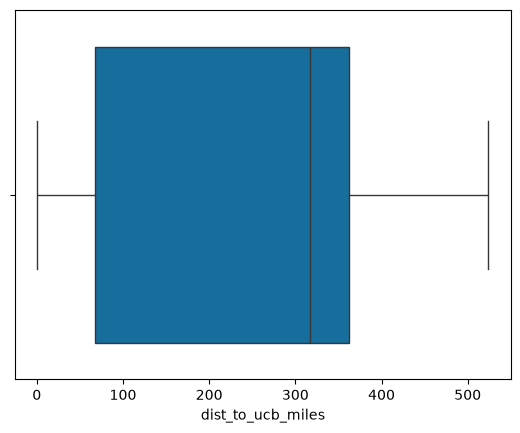

In [9]:
sns.boxplot(full, x='dist_to_ucb_miles')

**English:**
  
Make a boxplot of the values in `'dist_to_ucb'`.

**Seaborn code:**
  
`sns.boxplot(full, x='dist_to_ucb_miles')`

Again, you can observe a number of facts about the data. The line in the center of the box is the median, or second quartile (Q2). The left and right edges of the box are the first and third quartiles (Q1 and Q3), respectively.

The whiskers usually mark the most extreme data points that aren't determined to be outliers. This boxplot has no dots beyond the whiskers, so there are no outliers in this dataset. The ends of the left and right whiskers then represent the minimum and maximum of the data, respectively.

### Modality

Looking at the above boxplot, you might assume a few things about the shape of the corresponding histogram. For example, you might assume that there is a peak at the median. The median is also much closer to Q3 than to Q1, so you might assume that the histogram has a left skew. Let us take a look:

<Axes: xlabel='dist_to_ucb_miles', ylabel='Count'>

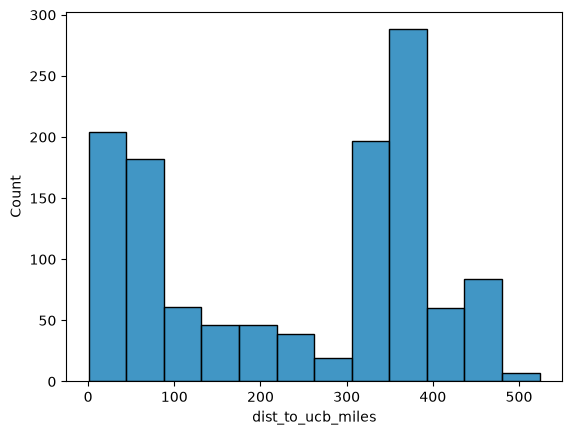

In [64]:
sns.histplot(full, x='dist_to_ucb_miles')

**English:**
  
Make a histogram of the values in `'dist_to_ucb_miles'`.

**Seaborn code:**

sns.histplot(full, x='dist_to_ucb_miles')

We noted at the end of the last chapter that distributions may have more than one **mode**, which you can see reflected in this histogram that appears to have two, or even three, separate peaks (modes). We also noted that this information is entirely hidden by boxplots.

We can increase the number of bins to get more detail as well.

<Axes: xlabel='dist_to_ucb_miles', ylabel='Count'>

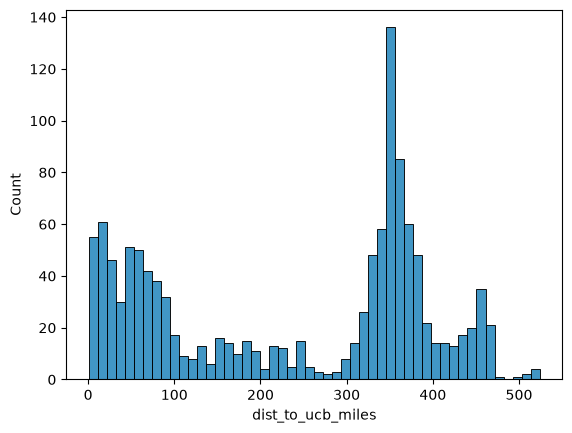

In [65]:
sns.histplot(full, x='dist_to_ucb_miles', bins=50)

**English:**
  
Make a histogram of the values in `'dist_to_ucb_miles'`, using 50 bins.

**Seaborn code:**
  
`sns.histplot(full, x='dist_to_ucb_miles', bins=50)`

It becomes fairly clear when looking at this more detailed histogram that there are three distinct peaks (maybe even four, if you count the spike close to 0 as distinct from the peak around 40 miles).

:::{note} Too many bins?
More bins is not always better! Having too much detail in a histogram can lead to noise that distracts from actually important patterns. Perhaps those anomalous spikes are of interest, but they can take away from the bigger picture.
:::

Why would this be? Here, it is helpful to check out a map of California, marked with population density.

```{image} images/cali_map.png
:alt: Map of California marked to show population centers. UC Berkeley's campus is marked on the map. There are dense areas very close to Berkeley, including a little to the south in the south Bay Area, and a little to the northeast in Sacramento. There is a very large dense area far to the south, around Los Angeles. There is another dense area a little south of Los Angeles, in San Diego.
:width: 400
```

1. There are a few areas of high population right near UC Berkeley, including San Francisco, San Jose, and Sacramento. This accounts for the peak closest to 0.
2. There is an area of very large population much farther away, in Los Angeles, which accounts for the tallest peak around 350 miles away from UC Berkeley.
3. There is a somewhat smaller area of high population just south of Los Angeles, which represents San Diego, and accounts for the peak around 450 miles.

Part of the reason we're working with this data set is because all of you are experts on high schools on applying to college on admissions and most of you uh you know the ones who are from California are probably also experts on you know California where schools are and so on. But in many data problems you work with many data sets you will not necessarily be the domain expert right and you will not be explaining things to people who are domain experts. 

So you want to like think about how do you communicate this kind of stuff out to other people. Uh so if we want to find out this information from the data one thing we can ask is for the counts of different cities right and how do we do this? Well, we take our city and what we want to do is for each city we want to count the number of rows, right? Count the number of schools, right? And how do we do that? Well, in our data, we count the number of rows for each city. 

So, this kind of operation for each something, do or calculate something is super common and you're going to see it all the time. If you have time at the end of class today we're going to like start getting into grouping, which is how we we do this. And if not, it'll be the topic for the majority of next week. Well, either way it'll be a majority next week. 

So in polars we can do something called value counts. We can take a column right which we extract a column using brackets and then we say dot value counts that gives us essentially we take you know every possible value count how many times it happens and then if we just get that then we just you know like get all the the the cities count to how many schools but if we sort them in descending order then we get something like this right where the most city with the most schools is at the top and so on all the way down to the bottom right and this is just the the top And so we can see already that we have LA and San Diego, right Which are like this blob over here, right? We have the Bay Area, right? San Jose, Oakland.

Some people will complain if I include Sacramento in the Bay Area because it's not technically but you know if we include it we can say that all of these correspond to what's going on over here right and Stockton again not quite the Bay Area but closeish and then last but not least we have the central valley right Fresno Bakersfield over here which corresponds to what's going on here right so we can think Right? Not just we can connect the visualization to what we know about the state of California to our summary of the data. 

All of these things are connected and we have to make the mental connections. Right? No amount of like prompting or or things like that will get you the insight and intuition that you can bring by knowing something about the problem. Okay. So, uh you know why is there variation? We talked about this uh in terms of distance. So for the next few minutes I want to talk about how application rates relate or correlate with free and reduced lunch percentage. Right?

So for every school remember I brought in I used the join to bring in data on the percentage of students receiving free or reduced price lunch which are we're going to call FRL. And we're going to use correlation because now we're not just looking at one variable at a time. Right? For one variable at a time, histograms are great. Uh box plots are great. But when we want to look at multiple variables at a time, what kind of visualization do we want to use? We can't use the histogram, right? Because histogram shows us the distribution of one. Yes. 

Yeah. A scatter plot, right? Not the only answer, but it's the answer we're going to uh use for now. We'll talk more about more uh types Remember this is what our data set looks like, right? We have for every school applied a metend number of enrolled in people in grade 12. We have the application rate column that is not shown in this version. Right? We divided applied by grade 12. And then we have these two new columns free and reduced and distance to Berkeley. So oops this is not the version I wanted. All right. While where is the version without the Okay, that's fine. Um, all right. 

So, this is what the scatter plot looks like, right? So, I have a scatter plot here of the uh on the x-axis right? This is a percent free reduced people getting percentage of people getting free reduced lunch. 

On the y- axis is the application rate. And how do I do this Well, I can use sns.catterplot. scatter plot or in this case since I'm adding a line on top of it I use snssreg plot for regression right so in day eight you saw regression using a line but is a line a good fit for this pattern that's happening here well probably not right it's kind of like if I look at the pattern right I see a whole bunch of schools that have relatively low application rates across a wide range of free reduced lunch percent and then over here with schools that have less I see a whole bunch of them with a lot of people applying right 

so there's kind of two distinct patterns and so maybe something other than a line is useful as a way of talking about this so again when you go to visualize something don't just you know run in uh you know type into a prompt model hey how do I uh do this you want to think what is the right way to analyze and think about this data. What kind of line should I use? 

Um there's a there have been a whole bunch of studies in the last like year, year and a half about pe how people who depend on large language models tend to have deterioration in their cognitive skills. Right? This has been shown there's this um study from the MIT Media Lab um where you know they had people write essays. There are studies of people online doing like math tasks. whole bunch of different uh ways that people do this that all generally have the same conclusion. If you uh use this, you know, if you use LLMs to rely on them too much, then you think you know more than you do. And people who rely on them too much tend to do worse when tested on the knowledge that they think they learn. 

Okay, so we're going to use something called Lois to help us with this. And this Lois is the way that we're constructing this little curved line. Uh if you remember from data eight right when you had that thing of heights you thought we thought about like well we can kind of make a line for every point we just like look at all the points nearby right and use that as our guess of the y right we look at all the points that are near an x use their average and use that as our guess for the y kind of how low works

so if we take people who are in this range and look at their uh this range of free reduced price lunch look at their average application rate it's here and do the same for here and for here and for here right so we average all the points nearby now it's an oversimplification it's slightly more sophisticated than this but a question I want to ask you is should every point have an equal influence on that line in other words are some points in this visualization more important than others should we have more weight assigned to some of these points what might be a reason that matters. Yes. 

Yeah. If the bin has more points, right, we should have given it more weight. But then within each of the individual points themselves, right, in the bin, like is there a reason that this point might be more or less important than this point? Right? Or like even these two points that are right next to each other, right? Is there a reason that one might be more important than another? Right? Well, again, we have to think each of these points corresponds to a school, right? What information about schools might make one school more or less relevant in our analysis? Yes. 

Yeah. The number of students, right? Maybe we should say, well, schools who have more students, we should think about them as having more weight than others. So in other words, we probably want to give more weight to bigger schools than to smaller schools. Um we'll skip this slide though and go to this one. So here I have the original scatter plot right up on the top left right where on the x axis you have number of 




students with free reduced price percent students free reduced price lunch y axis is application rate and then I have three versions where I've sized the points differently based on something related to number of students for B I've used grade 12 number of 12th graders as the size for C I've used total enrollment as the size and for D I've used the number of students who applied as the size.

So what does each one of these four plots communicate? Well, I would argue that plot A is a little misleading, right? If we think about these uh schools over here, right? Like this school over here is like getting a there's a lot of students who have uh free reduced price lunch but a relatively high application rate, right? Maybe there's something interesting going on with this school. But when I look at this in the version here, I can see that gosh, that school is really small, right? 

So maybe it's it's unique, maybe it's special, maybe it's a charter school, maybe there's something going on there, right? So point graph A is misleading because it emphasizes a lot of these points, right? These schools that are uh outliers over here, well, they're they show up as actually being quite small schools, right? So we have these schools that are quite small and so this visualization of in B kind of helps us see that right helps us see that hey some of these schools are bigger than others. C does basically the same thing except instead of uh number of 12th graders it's total enrolled. Right? 

So B and if we look at B and C kind of qualitatively and squint, we can see that they look pretty similar, right? They're  kind of conveying the same information. Um and we saw that there's a strong correlation between number of 12th graders and total number of people enrolled. And so yeah, sure there's, you know, people drop out as they go from year to year. Um, some schools offer more or fewer grades, but by and large B and C are very similar. 

So, we're going to like mostly focus on comparing B. What about D? What if we put the number of people who applied as the size? Well, here then we get a pattern that we should think about and expect, right? where the points near the top of the graph end up being bigger than the ones near the bottom, which kind of makes sense, right? Because there's a redundancy here, right? Because points higher up have a higher application rate, which means they have a higher percent of students applying. 

So, it kind of makes sense that if they have a higher percentage of students applying, they should also have more students applying. Not universally, right? We get some difference, right? Like we can see this school over here, right? Which is the same as this one, right? and this school over here which is the same as this one are pretty small but there's some amount of redundancy right there's a redundancy between the size and the y-axis is that redundancy necessarily bad no if I want to emphasize that right if I want to like really lean into that then maybe that's useful but there is some redundancy there 

okay so I want you to compare specifically B and D right the version where we have the size is the number of 12th graders and the size is the number who applied. And I want you to answer the question, which one of these two is better? Again, I'm being kind of vague here with better, right? So, you might have to start by answering what does better mean before you can answer which one is better. 

All right, take a minute, turn to the person next to you, and discuss and then vote. All right. So, let's see how people voted. So, we have more people saying B than D. Interesting. Um, so a lot of times when I show start by showing this, I start to see more people vote for the thing that happens to have more answers. Um, I do like to put questions up that are like a little tricky where the more intuitive answer is not necessarily the right one. 

So if you see you're voting for the less common answer, don't immediately think that you're wrong. Try to like think about why you voted for the answer you voted for. Okay, that being said, I don't think there is a right answer here, right? I think that there are good reasons why someone might want to choose B and there are good reasons why someone might want to choose D. Right? For most cases, I would probably go with B most of the time, more often, right?

So maybe B is like kind of sort of better. But again, in order to answer that, we have to think about what does better mean, right? B kind of clearly communicates where size corresponds to number of students. It's kind of intuitive. It's clear what's going on. When someone sees a bigger point, it means a bigger school. Smaller point means smaller school. Kind of matches up with our natural intuition. Whereas D, the size is doing something a little funky, right? where the size is the number of people who applied and again I said that's redundant with the y-axis which is the application rate 
 
that being said it is interesting right because if we're using B then we're kind of communicating about potential applicants right the size is telling us how big is the school how big is how many 12th graders are there what is the number of potential students who could apply whereas with D the size is telling us what are the number of actual applicants the size is telling me how many right emphasizing hey in these schools a lot of people applied and uh you know I'm have an easier time picking out the pattern of hey I had a lot of people who applied in these schools right where they had relatively low percent of free reduced price lunch whereas these schools right with high also high application rates had a lot fewer people applying Right? 
 
So there's kind of like easy to read off facts like that. So one isn't necessarily better than the other. It depends on what you're trying to communicate. So anytime you're deciding between a visual different ways of visualizing, which you often will be, think about what you're trying to communicate, who you're communicating it to, and what you want them to get out of it. 
 
So how do we go about doing the sizing? Right? This is the kind of thing where looking it up or using a large language model is a great way to do it. I personally can rarely remember all the details of how to specify this right with Seabor it's important to know that you know you pass in your data frame and then you can give it like the X the Y the size um we can also resize the points by number of potential applicants um but again there is no one right answer sometimes it can be helpful to like vary the sizes right to not have the sizes be um oh like you know I want uh like if we compare these two right both of these are sized by number of 12th graders
 
but notice that the second one this one it's kind of like emphasizing the point more right here the points all look kind of similar even though there's variation but here if I say the sizes are kind of like between one and 100 then that modifies the range of the sizes this is a great thing to use a large language model or to look up in the documentation right I've been using Seabor for like more than 10 years. I would not know how to do this off the top of my head if you asked me. I would have to go look it up. Um talked about this.

Um okay. So let's do some practice writing code. Right? A lot of the practice we've done has been on uh thinking about data. But you know we are going to expect you to know how to write some basic code in this class. So let's get some practice. So I want you to write Polers code that adds a new column to this data frame with the number of nth of 12th graders who get free reduced price lunch. Um and then after you do that think about is it possible that the calculation you made might be wrong. If so power why but just because it might be wrong doesn't mean don't do it means do it and be honest about how it might be off. 

All right feel free to discuss. If you want to xlike think by yourself for a moment before you discuss, totally cool, too. All right. If you haven't already, turn to the person next to you and discuss what you have. All right. And quick reminder on slido, right? How are these slidos work? The way it works is you scan the QR code and then log in and enter your thing. Um, if you are here in lecture, if you complete the slidos, we will mark your attendance. If you're watching this after the fact on the recording, then you'll need to for the ones where there's a correct answer, you'll need to get the correct answer uh in order to get full credit. 

Okay. So, how would we go about adding this column to our data set? Well, okay. And I know that sometimes when I move on to the slide, it closes the slido. This is an issue. Normally that does not happen. There's an issue with Slido. We're trying to resolve it. Um, if that happens to you, don't worry too much about it. Uh, we'll we'll figure it out. Okay. 

So, uh, how do we add the number of 12th graders as a new column? Well, in order to add a new column, we need to use the width columns uh method, right? So, we say df and we're calling it df new. If you didn't remember that, totally fine. It's not the point of this question, right? But we add a column by using the width columns method. And what is the new column we're adding? Well, it's the number of 12th graders who receive free reduced price free or reduced price lunch. 

How do we calculate the number? So, someone wanted in English describe to me what we need to do in order to calculate the number of 12th graders from the data that we have. Yes. Yeah. Uh in the cap basil cap. Yes. Yeah. Right. We can take the free reduced price lunch percentage multiply it by the number of 12th graders. 

Right. So we need to take the number the percent of free reduced price lunch which we get using pl.all of um I forget exactly what the column is called. We're going to say something like percent FRL and then multiply that by the number of 12th graders, right? And again, I'm being fast and loose about what the names of the columns are just because I forgot to put that on the slide. Um, but that's something where you always want to look it up. Okay? And then now I have the column, but I need to give it a name to name it the number of 12th graders. 

So the easiest way, well, there's two perfectly easy ways to do it. One is to put the name in front as a named argument. The other is to alias. Either way, totally fine. Num 12th graders with free or reduced price lunch. Right. So, this would be a perfectly valid answer. Well, it would be if I got gotten the column names right. Right. And if you don't like my handwriting, which totally fair. Um, here's a version that has it. Notice in this version I uh in the slide I added an extra step, right? I added this step called cast int. What is what is that about? 

Well, if I think about the if I want a estimate for the number of 12th graders and I take a percentage and multiply by something then I might get a fractional number of uh student right which maybe I don't want and so I might want to round so I can say passive of int say round and then I say alias okay questions on the code Great point, right? Question was, wouldn't the percentage of the uh free and reduced lunch be for the entire school, not just the number of 12th graders? Right? 

So, this gets to the second part of the question, uh, which is good. But before we get there, I want to answer any questions people might have about the code specifically. Um, and then we'll get into that.Any questions about how we wrote the code? Right, remember we pulled out the columns using plall, right? The two columns we wanted, we multiplied them and then we gave it a name either by putting the name in at the beginning as a named argument or by saying alalias at the end. 

All right, but the issue is yeah what you brought up right that um this percentage is for the whole school. Now, if the demographics of every class looks the same, right? If like the percentage is the same for the 12th grade class, for the 11th, for the 10th, for the 9th, then it's probably fine, right? Maybe we're a little off. So, maybe this is just an estimate, but we might be a little off, but probably not way off. But there might be scenarios where we are way off. 

Can somebody give an example of a real world event that might happen that would cause something like this to be way off? Yes. Exactly. Great point. Right. If we have a lot of students dropping out, those students who are dropping out might disproportionately be uh poorer and therefore more likely to be eligible for free reduced price lunch. Right? So it might be that more of those people are in ninth in the earlier grades and as they go into later grades um the people who are eligible are the ones who are more likely to drop out. 

Another example might be school closures, right? Often we see schools uh you know in poorer districts close and those students have to go to other schools, right? Which means in your ninth grade class then you have a huge addition of students many of whom might be uh more likely to be more el higher percent of eligibility for free reduced price lunch. Right? All kinds of reasons. Those are just like two examples. 

Um it's important to keep in mind when you do stuff like this that off the top of our heads like yeah this this seems perfectly reasonable but there might be times when this estimate might not be right. This is something you will do a lot as a data scientist. Make estimates, make computations like this, but keep in mind the limitations uh when you do. All right, we are good on time.

All right, so we have an answer, right? We kind of like identified some outliers, right, in these schools, right? some of the larger schools that maybe have um interesting relations between uh like you know more students eligible for free or reduced spice lunch but high application rates or vice versa but we kind of want to we haven't really looked at admission and attendance and we haven't really defined typical patterns but if we want to do that I want to first ask you a question of which plot is better right so again this is kind of like a recurring theme in our questions this uh for today. 

So I have two plots A and B, right? And in A this is like the version that's like the version B from before, right? Where the size is number of 12th graders. But in B I've simplified it down to just a single line where on the X-axis now I have free reduced life free reduced lunch uh percentage percentile. Right? So this is basically this has all the the 0 to 25th percentile. This has 25th to 50th and so on. And on the y-axis I just have the average application rate. Right? We kind of saw that lowest line that I was doing before. This is like an extreme uh version of that where I'm just doing it based on percentiles. 

So which of these two is better? Take a minute and discuss. All right, I'm going to close the voting in. So, please go ahead and vote if you have not already in five 4 3 2 1 01. Still climbing, climbing, climbing, climbing. Okay, starting to slow down. So, I see more people saying A than B, but it's kind of close, right? So, 5347. 

This is really interesting, right? That people are split on which one of these two is better. And again, anytime you I ask you the question of which one is better, you have to think about what does better mean? Better for what? Better in what way, right? And depending on the audience, we may want to show or not show every single data point. A has a lot going on, right? If I'm like, you know, come if I like just walk in off, you know, uh, off the street and I look at plot A, I'm like, wow, there's a lot going on in that graph, like, you know, I'm there's a ton of different schools. There's all these different sizes. I can spend a long time kind of eyeballing them. 

Do all the details really matter? Maybe, maybe not. Plot B on the other hand is very very simple right it's really easy to see that hey for schools in the uh lowest quartortile that is you know the bottom 25% of free reduced slice free free reduced price lunch percentage right that is the schools with the basically the schools with the most wellto-do students then the average application rate for those schools is really high 

whereas as soon as you go even to the second quartile right 25th% percentile and up, we start to see a much lower application rate. Right? Our application rate craters from 25% over here to 12 1/2 or less percentage over here and even further down over here. Right? So, it's very easy to have a clean takeaway from this, but that clean takeaway obscures the details of what's going on. 

So, there's a trade-off being made. I would kind of argue that these are like two extreme ends of a spectrum, right, between like lots of information and like very simplified. Um there's certainly a place for each, right? It depends on who you're communicating to. If you're talking to um you know, another analyst at the UC admissions office, maybe they're going to want to see this version because they're wanting they might say, "Oh, yeah, I know that school, right? That one school up in the top right. Yeah, I went and visited that school. I had a call with someone there. um I remember them. 

Whereas if you're talking with somebody who might not know as much about the the area and you want to like present a simple takeaway, you can do this. There are also ways to go in between, right? You can take this plot on the left, make all the data points kind of fade it out and overlay the line on top, right? There are lots of things you can do in between these two extremes. Not just because they're extreme doesn't mean they're they're bad or always never the right thing to do, but there's a huge spectrum of ways you can communicate with visualizations, which we'll talk a little bit more about next week and week after.

Um, okay. So, how would we generate this version of the graph? Well, in order to generate this, we have to think about how our visualizations correspond to our data. Right? In the scatter plot we were looking at earlier, I'm going to go back Here every single point corresponds to a school and in our data frame every single row corresponds to a school. Right? And this is generally like a mental model that you want to have for your visualizations where every row in your data should correspond to one point in a scatter plot or a line plot. 

And so that idea is called tidy data where each row represents one point. Right? If your data frame is set up like this, then it's called a tidy data frame. Um this is a concept that comes from the world of R, right? Which is another programming language. Um our writing R code with tidy data. Something called tidyverse actually looks very similar to polers. 

So in this case we have four points, right? We have one, two, three, four, right? And so we need four rows, right? Four data points in the plot, four rows in our data frame. What are those four rows? Well, for each one of those four, we need to know what the percentile of free reduced free reduced price lunch is. And we need to know the average application rate for all the schools that fall within that 25% right there. 

So every point right is going to have these two things about it. The X and the Y, right? Free reduce price lunch percentile and average application rate. And so we're going to need two columns, right? So we can see from this visualization that we're going to need four rows and two columns. Four rows because we have four data points and two columns because we're showing two pieces of information about each data point. If we also were showing the size, right, a little dot with the size at each one, then maybe we would need a third column. 

If we had multiple lines, right, if we had two lines, then we wouldn't have four points, we would have eight, right? And then we would need eight rows and we would need one more column to tell which line the point corresponds to. And so on and so on, right? So this is how we want to think about the relationship between the visualization and the plot that goes with it. So this is the data that we actually need in order to work with our in order to generate this plot. 

So how we actually go about generating it. Um before we do that a quick interlude on visualization code with Seabor. Again, I've kind of talked about this a little bit so far, right? The way Seabour code looks is we write sns the plotting function, right? Scatter plot, line plot, his plot, reg plot, whatever. And then the first argument is always going to be your data frame. And then the next few arguments are going to be like what is the x, what is the y, um what is the size, what is the color, and so on. And then at the end, you give it all the formatting arguments. 

This is where it's great to like just know how to look it up. Ask a large language model. Um, \ these are things you want to like think carefully about. These are things you want to like think about and then ask or or look up how to actually rate. These are the things that I've been doing this for, you know, more than 10 years and I never remember how. 

So, we've done all these operations so far, right? We've talked about how to view, uh, select, add columns, filter, sort. uh we talked about how to calculate summary statistics and now we've even learned how to visualize one-dimensional data with box plots and histograms and visualize 2D data with scatter plots and line plots. So what we're going to talk about at the in the last few minutes of today and spend a good chunk of next week on is grouping by a variable and then doing something within each group. usually aggregation but sometimes other stuff 

and the way this is going to look in English is for each unique value of some column do some calculation and again a little bit of data science wisdom the vast majority of the EDA work that you will do is grouping right it's answering these questions for each group what does this look like then maybe calculate the differences across these groups look at this across these different groups then slice the data a different way look at a different set of groups and make this uh same calculation or a different calculation. So knowing how to do groups thinking about it intuitively understanding the the basics of the writing code about it is a critical operation in being a good data scientist.

So how do we actually uh think about grouping? Again, we're going to talk about the conceptual part today and then get into the code uh next week. So, the way grouping works is using something called the split apply combine paradigm, right? Which is basically just like a fancy way of saying we're going to split up our data by groups, right? 

In this case, let's suppose we want to say for each city, we want to count the number of rows. For each unique value of city, count the number of rows. So we're going to do is we're going to split up our data into one subgroup per city, right? So we take all of our data, find all the places where city is A, B and C. This is like a simplified version with three cities A, B, and C. 

So step one, split it up by city. Take all the rows where city is A, all the rows where city is B, all the rows where city is C. Step two is apply. So do some operation on each of these groups and then step three is combine the results back. Right? So this fundamental operation, this fundamental series of steps is how every single group we're going to talk about in this class is going to work. Right? 

The group by operation that you learned in SQL, the grouping that you did in data 8, all of this works in the same basic way, right? We split by each and have one little subgroup for each of our uh groups right subframe and then we do our operation our application in this case count the number of rows and then step three is to combine them back. So this step two this application can be as complex as we want right we can say find the average of um the find the average number of people who uh applied minus the average number of people who were admitted right or we can do any number of operations in the supply step right and that might give us a sense of like what's the difference between application admission right 

but this paradigm thinking about it is first we split up our data then we apply some operation and then we combine the results back is the core of what we're going to be working with. Right? So in this case we've answered the question by counting the number of rows. Right? A has city A has three rows, city B has three rows. City C has only two. Right? Um oops did not mean to have the code there. Ignore the code. This is uh pandas which we're not uh covering. What if we want to compute the mean? Right? 

Well, if you want to compute the mean number of uh people who enroll in each city, then we say okay, do the same split. And now we have city A has 25, 30 and 35, right? One school with 25, one school with 30, one school with 35 and so on and so on. And then the thing we apply is compute the average of the enrolled column. Right? In this case, the average is 30. In this case, the average is 40. In this case, average is 25. and then combine the results back. Right? So that conceptual process right this description of for each unique value of city compute the mean number of students enrolled across its schools. Again we do it with the same uh apply split apply combine paradigm.

So next week uh you will get a chance to kind of work with this in in code and also see how we can use this to go deeper into our analysis of this data set. One thing I want to point out before we all leave is we have been spending like three lectures just on this question. We're going to continue to spend two more. This is not uncommon. I've worked on projects where we spent entire months just doing exploratory data analysis on one data set. So don't like feel weird that wow we spent so long on this data. This is exactly how real data science works. All right. Uh Jeremy will be teaching you all next week. I'll see you all in two weeks. I will have office hours today upstairs in 210 Wheeler.

In [1]:
import numpy as np
import polars as pl

## Dataset: California baby names

In today's lecture, we'll work with the `babynames` dataset, which contains information about the names of infants born in California.

The cell below pulls census data from a government website and then loads it into a usable form. The code shown here is outside of the scope of Data 100, but you're encouraged to dig into it if you are interested!

In [10]:
import urllib.request
import os.path
import zipfile

data_url = "https://www.ssa.gov/oact/babynames/state/namesbystate.zip"
local_filename = "data/babynamesbystate.zip"

# If the data exists don't download again
if not os.path.exists(local_filename): 
    with urllib.request.urlopen(data_url) as resp, open(local_filename, 'wb') as f:
        f.write(resp.read())

zf = zipfile.ZipFile(local_filename, 'r')

ca_name = 'STATE.CA.TXT'
field_names = ['State', 'Sex', 'Year', 'Name', 'Count']
with zf.open(ca_name) as fh:
    babynames = pl.read_csv(fh, has_header=False, new_columns=field_names)

babynames.head()

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1910,"""Mary""",295
"""CA""","""F""",1910,"""Helen""",239
"""CA""","""F""",1910,"""Dorothy""",220
"""CA""","""F""",1910,"""Margaret""",163
"""CA""","""F""",1910,"""Frances""",134


In [11]:
babynames.sample(n=5)

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""M""",1990,"""Juanpablo""",6
"""CA""","""F""",1999,"""Livia""",13
"""CA""","""M""",2014,"""Zaden""",11
"""CA""","""F""",2019,"""Janessa""",49
"""CA""","""F""",1919,"""Helena""",8


In [12]:
df = babynames

What happens when we want to use more complicated boolean masks?

In [13]:
# Note: The parentheses surrounding the code make it possible to 
# break the code into multiple lines for readability. But this is
# still a lot of code just to check for four names...

(
    babynames.filter((pl.col("Name")=="Bella") |
                     (pl.col("Name")=="Alex") |
                     (pl.col("Name")=="Narges") |
                     (pl.col("Name")=="Lisa"))
)

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1923,"""Bella""",5
"""CA""","""F""",1925,"""Bella""",8
"""CA""","""F""",1932,"""Lisa""",5
"""CA""","""F""",1936,"""Lisa""",8
"""CA""","""F""",1939,"""Lisa""",5
…,…,…,…,…
"""CA""","""M""",2018,"""Alex""",495
"""CA""","""M""",2019,"""Alex""",438
"""CA""","""M""",2020,"""Alex""",379


In [14]:
# A more concise method to achieve the above: The .is_in() method!
names = ["Bella", "Alex", "Narges", "Lisa"]
babynames.filter(pl.col("Name").is_in(names))

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1923,"""Bella""",5
"""CA""","""F""",1925,"""Bella""",8
"""CA""","""F""",1932,"""Lisa""",5
"""CA""","""F""",1936,"""Lisa""",8
"""CA""","""F""",1939,"""Lisa""",5
…,…,…,…,…
"""CA""","""M""",2018,"""Alex""",495
"""CA""","""M""",2019,"""Alex""",438
"""CA""","""M""",2020,"""Alex""",379


In [15]:
# What if we only want names that start with "N"?
babynames.filter(pl.col("Name").str.starts_with("N"))

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1910,"""Norma""",23
"""CA""","""F""",1910,"""Nellie""",20
"""CA""","""F""",1910,"""Nina""",11
"""CA""","""F""",1910,"""Nora""",6
"""CA""","""F""",1911,"""Nellie""",23
…,…,…,…,…
"""CA""","""M""",2022,"""Nilan""",5
"""CA""","""M""",2022,"""Niles""",5
"""CA""","""M""",2022,"""Nolen""",5


## Inspecting DataFrames: Useful Utility Functions

### Aggregation Methods

A `Series` carries the array functions you encountered in [Data 8](https://www.data8.org/su23/reference/#array-functions-and-methods) as methods you call on it.

In [16]:
yash_counts = babynames.filter(pl.col("Name")=="Yash")["Count"]
yash_counts

Count
i64
8
9
11
12
10
…
10
9
15


In [17]:
# Average number of babies named Yash each year
# Keep in mind that even if Python gives you 10 decimal places of precision, 
# you should think carefully about how much precision is meaningful!
# In this case, one decimal place or even no decimal places would be appropriate.
yash_counts.mean()

17.142857142857142

In [18]:
# Max number of babies named Yash born in any single year
max(yash_counts)

29

#### Built-In `Polars` Methods

There are many, *many* utility functions built into `Polars`, far more than we can possibly cover in lecture. You are encouraged to explore all the functionality outlined in the `Polars` [documentation](https://docs.pola.rs/api/python/stable/reference/index.html).

In [19]:
# A row is identified by its position in the table, counting from 0.
# with_row_index() writes those positions into a column of their own.
babynames.with_row_index().head()

index,State,Sex,Year,Name,Count
u32,str,str,i64,str,i64
0,"""CA""","""F""",1910,"""Mary""",295
1,"""CA""","""F""",1910,"""Helen""",239
2,"""CA""","""F""",1910,"""Dorothy""",220
3,"""CA""","""F""",1910,"""Margaret""",163
4,"""CA""","""F""",1910,"""Frances""",134


In [20]:
# Sorting hands out new positions, so record the current ones first if you want them later.
babynames.with_row_index("original_position").sort("Name").head()

original_position,State,Sex,Year,Name,Count
u32,str,str,i64,str,i64
366001,"""CA""","""M""",2008,"""Aadan""",7
369120,"""CA""","""M""",2009,"""Aadan""",6
384005,"""CA""","""M""",2014,"""Aadan""",5
398211,"""CA""","""M""",2019,"""Aadarsh""",6
362040,"""CA""","""M""",2007,"""Aaden""",20


In [21]:
# Returns the columns
babynames.columns

['State', 'Sex', 'Year', 'Name', 'Count']

In [22]:
# Returns the shape of the object in the format (num_rows, num_columns)
babynames.shape

(407428, 5)

In [23]:
# The total number of entries in the object, equal to num_rows * num_columns
babynames.height * babynames.width

2037140

In [24]:
# Returns the number of rows in the dataframe
len(babynames)

407428

In [25]:
# What summary statistics can we describe?
babynames.describe()

statistic,State,Sex,Year,Name,Count
str,str,str,f64,str,f64
"""count""","""407428""","""407428""",407428.0,"""407428""",407428.0
"""null_count""","""0""","""0""",0.0,"""0""",0.0
"""mean""",null,null,1985.733609,null,79.543456
"""std""",null,null,27.00766,null,293.698654
"""min""","""CA""","""F""",1910.0,"""Aadan""",5.0
"""25%""",null,null,1969.0,null,7.0
"""50%""",null,null,1992.0,null,13.0
"""75%""",null,null,2008.0,null,38.0
"""max""","""CA""","""M""",2022.0,"""Zyrus""",8260.0


In [26]:
# Our statistics are slightly different when working with categorical data (string columns)
babynames["Sex"].describe()

statistic,value
str,str
"""count""","""407428"""
"""null_count""","""0"""
"""min""","""F"""
"""max""","""M"""


In [27]:
# Randomly sample a row from the DataFrame.
babynames.sample()

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",2020,"""Daya""",7


In [28]:
# Rerun this cell a few times – you'll get different results!
babynames.sample(5)[:, 2:]

Year,Name,Count
i64,str,i64
2022,"""Dream""",61
2009,"""Gabriele""",5
1964,"""Marc""",401
2008,"""Itzel""",288
1969,"""Yolonda""",10


In [29]:
# Sampling with replacement requires the argument with_replacement=True.
# Sampling without replacement is the default behavior.
babynames[:10].sample(4, with_replacement=True)

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1910,"""Evelyn""",126
"""CA""","""F""",1910,"""Ruth""",128
"""CA""","""F""",1910,"""Virginia""",101
"""CA""","""F""",1910,"""Elizabeth""",93


In [30]:
# Multi-line chaining
result = (
    babynames.filter(pl.col("Year") == 2000)
    .sample(4, with_replacement=True)[:, 2:]
)
result

Year,Name,Count
i64,str,i64
2000,"""Joselyn""",91
2000,"""Wynter""",7
2000,"""Sahar""",21
2000,"""Adin""",13


In [31]:
# Count the number of times each unique value occurs in a Series,
# reporting the result as a two-column DataFrame ranked from most to least common.
babynames["Sex"].value_counts(sort=True)

Sex,count
str,u32
"""F""",239537
"""M""",167891


In [32]:
# Return all of the unique values in the Series.
babynames["Name"].unique()

Name
str
"""Jovonna"""
"""Zoraya"""
"""Alyn"""
"""Neah"""
"""Britteny"""
…
"""Isadora"""
"""Jeovany"""
"""Markham"""


## Adding, Removing, and Modifying Columns

To add a column, hand `with_columns()` a `Series` or an expression under the name you want. The method returns a new table, so assign the result back.

In [33]:
# Create a Series of the length of each name.
babyname_lengths = babynames["Name"].str.len_chars()

# Add that series as a column named "name_lengths"
babynames = babynames.with_columns(name_lengths = babyname_lengths)

babynames

State,Sex,Year,Name,Count,name_lengths
str,str,i64,str,i64,u32
"""CA""","""F""",1910,"""Mary""",295,4
"""CA""","""F""",1910,"""Helen""",239,5
"""CA""","""F""",1910,"""Dorothy""",220,7
"""CA""","""F""",1910,"""Margaret""",163,8
"""CA""","""F""",1910,"""Frances""",134,7
…,…,…,…,…,…
"""CA""","""M""",2022,"""Zayvier""",5,7
"""CA""","""M""",2022,"""Zia""",5,3
"""CA""","""M""",2022,"""Zora""",5,4


To modify a column, build the new values as an expression and pass it to `with_columns()` under the column's existing name.

In [34]:
# Modify the "name_lengths" column to be one less than its original value.
babynames = babynames.with_columns(name_lengths = pl.col("name_lengths") - 1)
babynames

State,Sex,Year,Name,Count,name_lengths
str,str,i64,str,i64,u32
"""CA""","""F""",1910,"""Mary""",295,3
"""CA""","""F""",1910,"""Helen""",239,4
"""CA""","""F""",1910,"""Dorothy""",220,6
"""CA""","""F""",1910,"""Margaret""",163,7
"""CA""","""F""",1910,"""Frances""",134,6
…,…,…,…,…,…
"""CA""","""M""",2022,"""Zayvier""",5,6
"""CA""","""M""",2022,"""Zia""",5,2
"""CA""","""M""",2022,"""Zora""",5,3


Rename a column using the `.rename()` method.

In [35]:
# Rename "name_lengths" to "Length".
babynames = babynames.rename({"name_lengths":"Length"})
babynames

State,Sex,Year,Name,Count,Length
str,str,i64,str,i64,u32
"""CA""","""F""",1910,"""Mary""",295,3
"""CA""","""F""",1910,"""Helen""",239,4
"""CA""","""F""",1910,"""Dorothy""",220,6
"""CA""","""F""",1910,"""Margaret""",163,7
"""CA""","""F""",1910,"""Frances""",134,6
…,…,…,…,…,…
"""CA""","""M""",2022,"""Zayvier""",5,6
"""CA""","""M""",2022,"""Zia""",5,2
"""CA""","""M""",2022,"""Zora""",5,3


Remove a column using `.drop()`.

In [36]:
# Remove our new "Length" column.
babynames = babynames.drop("Length")
babynames

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1910,"""Mary""",295
"""CA""","""F""",1910,"""Helen""",239
"""CA""","""F""",1910,"""Dorothy""",220
"""CA""","""F""",1910,"""Margaret""",163
"""CA""","""F""",1910,"""Frances""",134
…,…,…,…,…
"""CA""","""M""",2022,"""Zayvier""",5
"""CA""","""M""",2022,"""Zia""",5
"""CA""","""M""",2022,"""Zora""",5


## Sorting

In [37]:
# Sort a DataFrame – there are lots of Michaels in California.
babynames.sort("Count")

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1910,"""Adelaide""",5
"""CA""","""F""",1910,"""Adele""",5
"""CA""","""F""",1910,"""Adrienne""",5
"""CA""","""F""",1910,"""Althea""",5
"""CA""","""F""",1910,"""Antonia""",5
…,…,…,…,…
"""CA""","""M""",1970,"""Michael""",8196
"""CA""","""M""",1969,"""Michael""",8245
"""CA""","""M""",1990,"""Michael""",8246


In [38]:
# Sort a Series. Only the values come back, in their new order.
babynames["Name"].sort()

Name
str
"""Aadan"""
"""Aadan"""
"""Aadan"""
"""Aadarsh"""
"""Aaden"""
…
"""Zyrah"""
"""Zyrah"""
"""Zyrah"""


### Custom sorting

#### Approach 1: Create a temporary column

In [39]:
# Create a Series of the length of each name.
babyname_lengths = babynames["Name"].str.len_chars()

# Add a column named "name_lengths" that includes the length of each name.
babynames = babynames.with_columns(name_lengths = babyname_lengths)
babynames.head(5)

State,Sex,Year,Name,Count,name_lengths
str,str,i64,str,i64,u32
"""CA""","""F""",1910,"""Mary""",295,4
"""CA""","""F""",1910,"""Helen""",239,5
"""CA""","""F""",1910,"""Dorothy""",220,7
"""CA""","""F""",1910,"""Margaret""",163,8
"""CA""","""F""",1910,"""Frances""",134,7


In [40]:
# Sort by the temporary column.
babynames = babynames.sort(by="name_lengths", descending=True)
babynames.head(5)

State,Sex,Year,Name,Count,name_lengths
str,str,i64,str,i64,u32
"""CA""","""F""",1986,"""Mariadelosangel""",5,15
"""CA""","""M""",1987,"""Franciscojavier""",5,15
"""CA""","""M""",1988,"""Franciscojavier""",10,15
"""CA""","""M""",1989,"""Franciscojavier""",6,15
"""CA""","""M""",1991,"""Ryanchristopher""",7,15


In [41]:
# Drop the 'name_length' column.
babynames = babynames.drop("name_lengths")
babynames.head(5)

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1986,"""Mariadelosangel""",5
"""CA""","""M""",1987,"""Franciscojavier""",5
"""CA""","""M""",1988,"""Franciscojavier""",10
"""CA""","""M""",1989,"""Franciscojavier""",6
"""CA""","""M""",1991,"""Ryanchristopher""",7


#### Approach 2: Sorting on an expression

In [42]:
# Same as above, but the sort key is computed inline, so there is no temporary column to create and drop.
babynames.sort(pl.col("Name").str.len_chars(), descending=True).head()

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1986,"""Mariadelosangel""",5
"""CA""","""M""",1987,"""Franciscojavier""",5
"""CA""","""M""",1988,"""Franciscojavier""",10
"""CA""","""M""",1989,"""Franciscojavier""",6
"""CA""","""M""",1991,"""Ryanchristopher""",7


#### Approach 3: Sorting Using the `map_elements` Method

We can also use `map_elements` if we want to use an arbitrarily defined Python function. Suppose we want to sort by the number of occurrences of "dr" plus the number of occurences of "ea".

In [43]:
# First, define a function to count 
# the number of times "dr" or "ea" appear in each name.
def dr_ea_count(string):
    return string.count('dr') + string.count('ea')

# Then, use `map_elements` to apply `dr_ea_count` to each name in the "Name" column.
babynames = babynames.with_columns(
    dr_ea_count = pl.col("Name").map_elements(dr_ea_count, return_dtype=pl.Int64)
)

# Sort the DataFrame by the new "dr_ea_count" column
# so we can see our handiwork.
babynames = babynames.sort(by="dr_ea_count", descending=True)
babynames.head()

State,Sex,Year,Name,Count,dr_ea_count
str,str,i64,str,i64,i64
"""CA""","""F""",1986,"""Deandrea""",6,3
"""CA""","""F""",1988,"""Deandrea""",5,3
"""CA""","""F""",1990,"""Deandrea""",5,3
"""CA""","""F""",1994,"""Leandrea""",5,3
"""CA""","""M""",1985,"""Deandrea""",6,3


In [44]:
# Drop the `dr_ea_count` column.
babynames = babynames.drop("dr_ea_count")
babynames.head(5)

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1986,"""Deandrea""",6
"""CA""","""F""",1988,"""Deandrea""",5
"""CA""","""F""",1990,"""Deandrea""",5
"""CA""","""F""",1994,"""Leandrea""",5
"""CA""","""M""",1985,"""Deandrea""",6


### Example: Common names in certain years

In [45]:
names_06 = babynames.filter(pl.col('Year') == 2006)
boys_06 = names_06.filter(pl.col('Sex') == 'M')
girls_06 = names_06.filter(pl.col('Sex') == 'F')

In [46]:
boys_06.sort('Count').tail(8)

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""M""",2006,"""Joshua""",3031
"""CA""","""M""",2006,"""Jose""",3096
"""CA""","""M""",2006,"""Andrew""",3127
"""CA""","""M""",2006,"""David""",3158
"""CA""","""M""",2006,"""Jacob""",3199
"""CA""","""M""",2006,"""Angel""",3690
"""CA""","""M""",2006,"""Anthony""",3776
"""CA""","""M""",2006,"""Daniel""",3830


In [47]:
girls_06.sort('Count').tail(8)

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",2006,"""Emma""",1546
"""CA""","""F""",2006,"""Sophia""",1983
"""CA""","""F""",2006,"""Natalie""",2227
"""CA""","""F""",2006,"""Samantha""",2350
"""CA""","""F""",2006,"""Mia""",2453
"""CA""","""F""",2006,"""Ashley""",2606
"""CA""","""F""",2006,"""Isabella""",2801
"""CA""","""F""",2006,"""Emily""",3104


In [48]:
names_80s = babynames.filter(pl.col('Year').is_in(list(range(1980, 1990))))
boys_80s = names_80s.filter(pl.col('Sex') == 'M')
girls_80s = names_80s.filter(pl.col('Sex') == 'F')

In [49]:
display(girls_80s.sort('Count').tail(8))
display(boys_80s.sort('Count').tail(8))

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1980,"""Jennifer""",5612
"""CA""","""F""",1981,"""Jennifer""",5628
"""CA""","""F""",1982,"""Jennifer""",5813
"""CA""","""F""",1983,"""Jennifer""",5830
"""CA""","""F""",1986,"""Jessica""",5964
"""CA""","""F""",1988,"""Jessica""",6493
"""CA""","""F""",1989,"""Jessica""",6541
"""CA""","""F""",1987,"""Jessica""",6846


State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""M""",1982,"""Michael""",7162
"""CA""","""M""",1985,"""Michael""",7216
"""CA""","""M""",1986,"""Michael""",7263
"""CA""","""M""",1983,"""Michael""",7397
"""CA""","""M""",1987,"""Michael""",7452
"""CA""","""M""",1984,"""Michael""",7479
"""CA""","""M""",1988,"""Michael""",7761
"""CA""","""M""",1989,"""Michael""",7858


## Slido Exercises

### Which of the following statements returns a DataFrame of the first 3 baby names for boys in 2006?

In [50]:
mask1 = (babynames['Year'] == 2006) & (babynames['Sex'] == 'M')
mask2 = (babynames['Year'] == 2006) | (babynames['Sex'] == 'M')

In [51]:
babynames.filter(mask1).select(['Name', 'Sex', 'Count'])

Name,Sex,Count
str,str,i64
"""Leandro""","""M""",46
"""Andreas""","""M""",36
"""Deandre""","""M""",36
"""Leandre""","""M""",7
"""Adrean""","""M""",8
…,…,…
"""Ab""","""M""",7
"""Sy""","""M""",6
"""Aj""","""M""",5


In [52]:
babynames.filter(mask1)[:3, 'Name']

Name
str
"""Leandro"""
"""Andreas"""
"""Deandre"""


In [53]:
babynames.filter(mask2).select(['Name', 'Sex', 'Count'])[:3]

Name,Sex,Count
str,str,i64
"""Deandrea""","""M""",6
"""Alexandrea""","""F""",19
"""Joseandres""","""M""",5


In [54]:
babynames.filter(mask2).select(['Name', 'Sex', 'Count']).head(3)

Name,Sex,Count
str,str,i64
"""Deandrea""","""M""",6
"""Alexandrea""","""F""",19
"""Joseandres""","""M""",5


In [55]:
babynames[['Name', 'Sex', 'Count']].filter(mask1)[:3]

Name,Sex,Count
str,str,i64
"""Leandro""","""M""",46
"""Andreas""","""M""",36
"""Deandre""","""M""",36


#### What does this result mean?

In [56]:
babynames['Name'].value_counts(sort=True)

Name,count
str,u32
"""Jean""",223
"""Francis""",221
"""Guadalupe""",218
"""Jessie""",217
"""Marion""",214
…,…
"""Ku""",1
"""Lo""",1
"""Wa""",1


#### Which of the following returns `'b'`?

In [57]:
df = pl.DataFrame({
    "a": ['c', 'b', 'a'],
    "b": ['b', 'c', 'a'],
    "c": ['c', 'a', 'b']
})
df

a,b,c
str,str,str
"""c""","""b""","""c"""
"""b""","""c""","""a"""
"""a""","""a""","""b"""


In [58]:
df.drop('a')['b'][1]

'c'

In [59]:
df

a,b,c
str,str,str
"""c""","""b""","""c"""
"""b""","""c""","""a"""
"""a""","""a""","""b"""


In [60]:
df.filter(pl.col('a').is_in(['b','c']))[0,1]

'b'

In [61]:
df

a,b,c
str,str,str
"""c""","""b""","""c"""
"""b""","""c""","""a"""
"""a""","""a""","""b"""


In [62]:
df.rename({'b':'a', 'a':'b'})[0,'b']

'c'

#### Which of the following extracts the rows of `df` where the values in column `A` are at least as big as the smallest value in column `B`?

In [63]:
# Sample DataFrame for experimentation!
df = pl.DataFrame({
    "A": [2, 3, 4],
    "B": [3, 5, 5],
})
df

A,B
i64,i64
2,3
3,5
4,5


In [46]:
# df.filter(pl.col('A') >= pl.col('B').min())

In [47]:
# df.filter(pl.col('A') >= df['B'].sort(descending=True)[0])

In [48]:
# df.filter(pl.col('A') >= df['B'].value_counts(sort=True).tail(1))